# BirdsEye sandbox — range short-straddle

Runs the `RangeShortStraddle` example strategy on SPY 0-DTE (raw `/mnt` data,
days taken from the manifest split) and prints the result stats.

In [1]:
from engine import BirdsEye
from strategies.range_short_straddle import RangeShortStraddle

# All paths (manifest, intern-project dir) come from BirdsEye/.env — nothing hardcoded here.
be = BirdsEye(
    strategy_cls    = RangeShortStraddle,
    index           = "SPY",
    split           = "train",                           # "val" / "test" to evaluate
    strategy_kwargs = {"lots": 1, "range_bps_max": 15.0},
    lot_size        = 100,
    starting_cash   = 1_000_000.0,
    n_workers       = 40,
    # days=["20240102", "20240104"],                     # uncomment for a quick subset
)
res = be.run()

[birdseye] log -> /home/satwik/Project/BirdsEye/logs/SPY_train_20260615_120445.log


=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,50,-18.5,29.0,-47.5
20240104,50,22.5,28.0,-5.5
20240105,42,39.5,25.0,14.5
20240109,46,-25.5,26.5,-52.0
20240110,54,-17.0,30.0,-47.0
...,...,...,...,...
20250804,54,53.0,29.0,24.0
20250806,46,-5.0,25.5,-30.5
20250807,30,36.5,19.0,17.5


=== aggregate stats ===
  n_days          : 277
  total_pnl       : -4784.0
  avg_day         : -17.27
  pct_pos_days    : 0.36
  pct_neg_days    : 0.58
  avg_win         : 14.4
  avg_loss        : -38.66
  best_day        : 71.0
  worst_day       : -135.0
  win_rate        : 0.36
  cagr            : -0.0
  calmar          : -0.92
  maxDD_pct       : -0.0
  churn_per_day   : 0.0
  daily_maxDD     : -4757.5
  intraday_maxDD  : -220.0
  total_costs     : 7023.0
  n_fills         : 10864


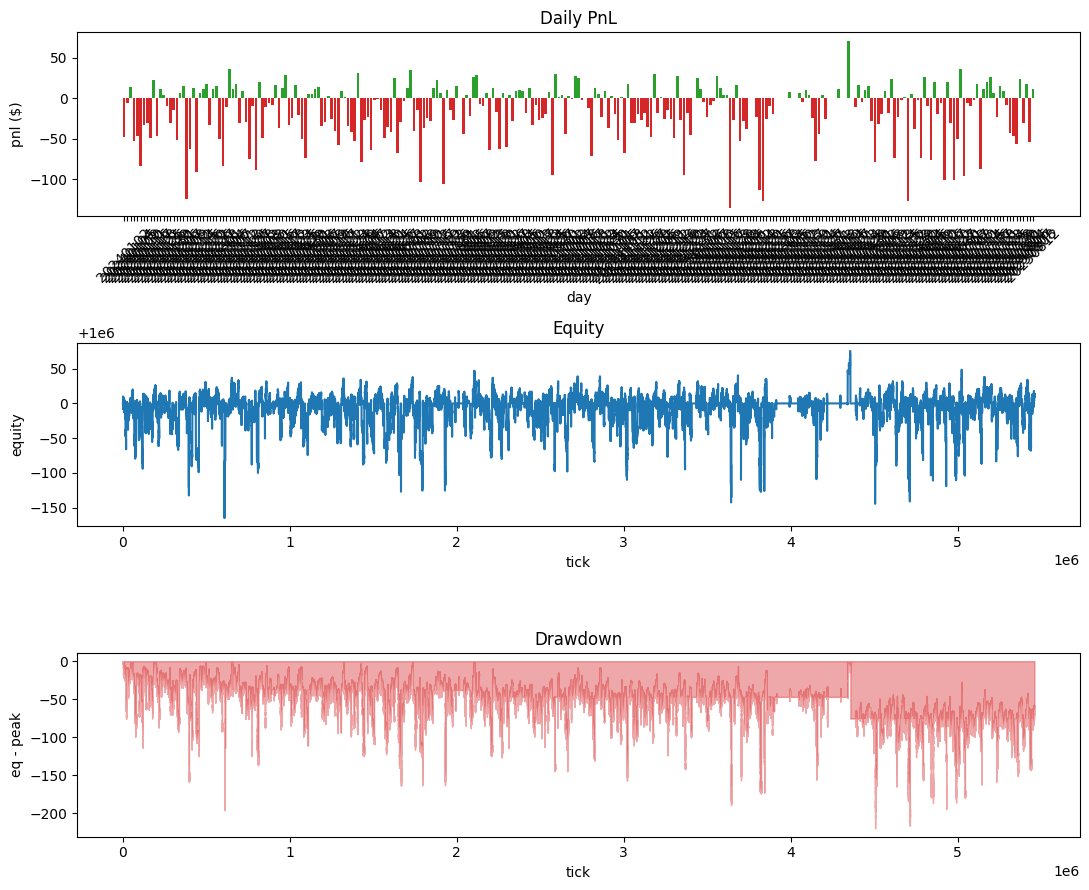

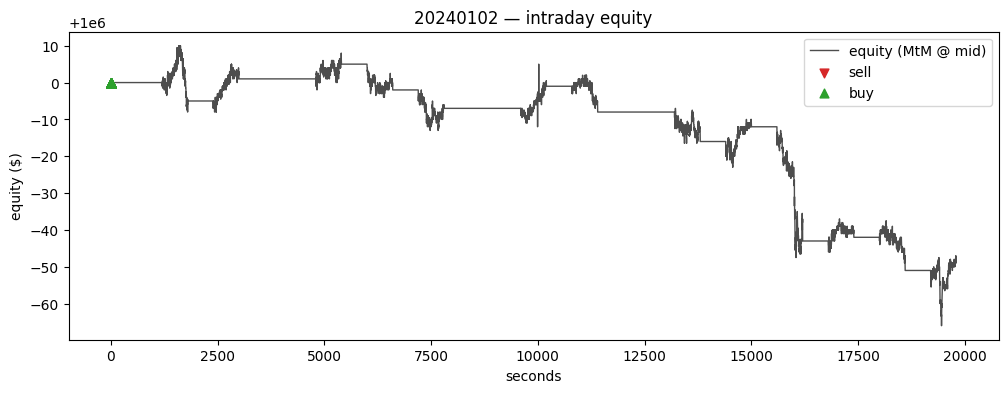

=== trade ledger: 10864 fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,exe_cost,state,signal,note,alpha_sec,alpha_spot,alpha_atm,alpha_range_bps,alpha_decision_now
0,20240102,1201,471.0,CE,SELL,1.0,1.23,0.0,0.0,0.5,0.5,SHORT,calm_entry,,1200,471.40,471.0,14.64,1
1,20240102,1201,471.0,PE,SELL,1.0,0.82,0.0,0.0,0.5,0.5,SHORT,calm_entry,,1200,471.40,471.0,14.64,1
2,20240102,1801,471.0,CE,BUY,1.0,1.61,0.0,0.0,1.0,1.0,WAIT,hold_elapsed,square off,1800,472.14,472.0,18.64,0
3,20240102,1801,471.0,PE,BUY,1.0,0.46,0.0,0.0,0.5,0.5,WAIT,hold_elapsed,square off,1800,472.14,472.0,18.64,0
4,20240102,2401,472.0,CE,SELL,1.0,1.00,0.0,0.0,0.5,0.5,SHORT,calm_entry,,2400,472.26,472.0,14.82,1
5,20240102,2401,472.0,PE,SELL,1.0,0.74,0.0,0.0,0.5,0.5,SHORT,calm_entry,,2400,472.26,472.0,14.82,1
6,20240102,3001,472.0,CE,BUY,1.0,0.88,0.0,0.0,0.5,0.5,WAIT,hold_elapsed,square off,3000,472.07,472.0,10.38,0
7,20240102,3001,472.0,PE,BUY,1.0,0.78,0.0,0.0,0.5,0.5,WAIT,hold_elapsed,square off,3000,472.07,472.0,10.38,0
8,20240102,4801,472.0,CE,SELL,1.0,0.57,0.0,0.0,0.5,0.5,SHORT,calm_entry,,4800,471.67,472.0,12.51,1
9,20240102,4801,472.0,PE,SELL,1.0,0.90,0.0,0.0,0.5,0.5,SHORT,calm_entry,,4800,471.67,472.0,12.51,1


fills by signal:


,count,sum
signal,,
calm_entry,5642,3268.0
hold_elapsed,5222,3755.0


=== per-second log 20240102: 19776 rows ===


,timestamp,spot,atm,state,sec,range_bps,decision_now
2000,2002,472.53,473.0,WAIT,2002.0,26.05,False
2001,2003,472.54,473.0,WAIT,2003.0,26.05,False
2002,2004,472.52,473.0,WAIT,2004.0,26.05,False
2003,2005,472.53,473.0,WAIT,2005.0,26.05,False
2004,2006,472.53,473.0,WAIT,2006.0,26.05,False


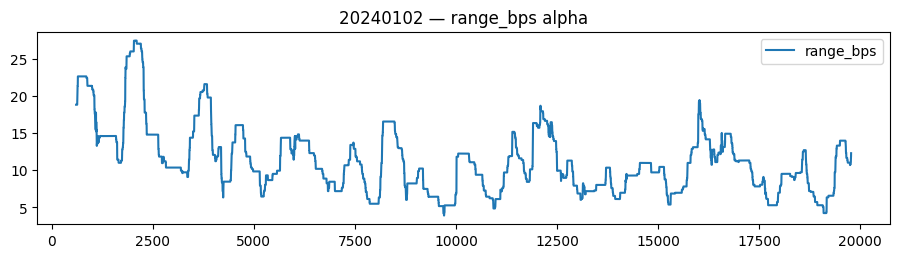

In [2]:
import matplotlib.pyplot as plt

DAY = res.days[0]          # first day in the run (any value in res.days works)

# ---- 1. per-day summary table ----
print("=== per-day summary ===")
display(res.summary)

# ---- 2. aggregate stats ----
print("=== aggregate stats ===")
for k, v in res.stats().items():
    print(f"  {k:<16}: {v}")

# ---- 3. plots: daily PnL / stitched equity / drawdown ----
res.tearsheet()
plt.show()

# ---- 4. single-day deep dive: intraday MtM with buy/sell markers ----
res.plot_day(DAY)
plt.show()

# ---- 5. trade ledger (all days) ----
led = res.Tradelog()
print(f"=== trade ledger: {len(led)} fills ===")
display(led.head(10))                                  # alpha_* cols show fire-time values
print("fills by signal:")
display(led.groupby("signal")["exe_cost"].agg(["count", "sum"]).round(2))

# ---- 6. per-second log for one day ----
sl = res.perseclog(DAY)
print(f"=== per-second log {DAY}: {len(sl)} rows ===")
display(sl.iloc[2000:2005])                            # spot, atm, state, every alpha
sl.plot(y="range_bps", figsize=(11, 2.5), title=f"{DAY} — range_bps alpha")
plt.show()